In [ ]:
# Copy paste kode ini ke Colab, lalu RUN (tekan Shift+Enter)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (pastikan file sudah di-upload)
header = pd.read_csv('penjualan_header_ready.csv')
detail = pd.read_csv('penjualan_detail_ready.csv')

print("✅ Data loaded successfully!")
print(f"Header transactions: {len(header)} rows")
print(f"Detail items: {len(detail)} rows")
print(f"\nColumns in header:\n{header.columns.tolist()}")

✅ Data loaded successfully!
Header transactions: 177 rows
Detail items: 86 rows

Columns in header:
['transaksi_id', 'no_transaksi', 'cabang_id', 'karyawan_id', 'pelanggan_id', 'tgl_transaksi', 'tanggal', 'tahun', 'bulan', 'nama_bulan', 'jam', 'subtotal', 'diskon_persen', 'diskon_nominal', 'pajak_persen', 'pajak_nominal', 'total_bayar', 'metode_bayar', 'jumlah_bayar', 'kembalian', 'poin_didapat', 'poin_dipakai', 'status_transaksi', 'keterangan', 'kode_cabang', 'nama_cabang', 'kota_cabang', 'provinsi_cabang', 'status_cabang', 'kode_karyawan', 'nama_kasir', 'jabatan', 'status_karyawan', 'shift', 'kode_member', 'nama_pelanggan', 'jenis_kelamin', 'tgl_lahir', 'kota_pelanggan', 'poin', 'tgl_daftar', 'status_pelanggan']


1. Memahami Struktur Dataset
Periksa jumlah data, jumlah variabel, tipe data, dan beberapa contoh record.



In [ ]:
print('Jumlah baris, kolom:', header.shape)
print('Tipe data:')
print(header.dtypes)
print('Contoh 5 baris awal:')
display(header.head())

Jumlah baris, kolom: (177, 42)
Tipe data:
transaksi_id                 int64
no_transaksi                object
cabang_id                    int64
karyawan_id                  int64
pelanggan_id               float64
tgl_transaksi       datetime64[ns]
tanggal                     object
tahun                        int64
bulan                    period[M]
nama_bulan                  object
jam                          int64
subtotal                   float64
diskon_persen                int64
diskon_nominal               int64
pajak_persen                 int64
pajak_nominal                int64
total_bayar                float64
metode_bayar                object
jumlah_bayar               float64
kembalian                  float64
poin_didapat                 int64
poin_dipakai                 int64
status_transaksi            object
keterangan                  object
kode_cabang                 object
nama_cabang                 object
kota_cabang                 object
provinsi_caba

,transaksi_id,no_transaksi,cabang_id,karyawan_id,pelanggan_id,tgl_transaksi,tanggal,tahun,bulan,nama_bulan,...,status_karyawan,shift,kode_member,nama_pelanggan,jenis_kelamin,tgl_lahir,kota_pelanggan,poin,tgl_daftar,status_pelanggan
0,1,TRX-CB1-20230102-001,1,1,1.0,2023-01-02 08:35:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,MBR-00001,Budi Santoso,L,1985-05-12,Denpasar,1250.0,2023-01-15,AKTIF
1,2,TRX-CB1-20230102-002,1,1,NaN,2023-01-02 09:10:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,TRX-CB1-20230102-003,1,1,2.0,2023-01-02 10:20:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,MBR-00002,Ni Wayan Eka,P,1990-08-23,Denpasar,870.0,2023-01-20,AKTIF
3,4,TRX-CB2-20230103-001,2,4,NaN,2023-01-03 08:45:00,2023-01-03,2023,2023-01,January,...,AKTIF,Pagi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,TRX-CB2-20230103-002,2,4,4.0,2023-01-03 10:30:00,2023-01-03,2023,2023-01,January,...,AKTIF,Pagi,MBR-00004,Komang Ayu,P,1995-03-17,Badung,2100.0,2023-02-14,AKTIF


## Temuan Isu Kualitas Data (Missing Values)

### Analisis Missing Values di DataFrame `detail`

In [ ]:
print('Missing value per kolom di detail DataFrame:')
display(detail.isna().sum().sort_values(ascending=False))

print('Jumlah baris duplikat penuh di detail DataFrame:', detail.duplicated().sum())

Missing value per kolom di detail DataFrame:


,0
jenis_kelamin,21
kota_pelanggan,21
kode_member,21
nama_pelanggan,21
pelanggan_id,21
detail_id,0
bulan,0
nama_bulan,0
jam,0
transaksi_id,0


Jumlah baris duplikat penuh di detail DataFrame: 0


### Ringkasan Isu Kualitas Data

Berdasarkan analisis missing values pada kedua DataFrame:

**DataFrame `header`:**

*   Banyak kolom terkait informasi pelanggan (`nama_pelanggan`, `status_pelanggan`, `tgl_daftar`, `poin`, `kota_pelanggan`, `tgl_lahir`, `jenis_kelamin`, `kode_member`, `pelanggan_id`) memiliki sejumlah besar nilai yang hilang (sekitar 93-94 baris), menunjukkan bahwa tidak semua transaksi terkait dengan pelanggan terdaftar atau data pelanggan tidak selalu dicatat.
*   Kolom `keterangan` memiliki missing values terbanyak (153), yang mungkin menunjukkan bahwa kolom ini opsional atau jarang diisi.
*   `kota_cabang` (3 missing values) dan `metode_bayar` (1 missing value) juga memiliki sedikit nilai yang hilang, yang perlu diperiksa lebih lanjut.
*   Tidak ada baris duplikat penuh di DataFrame `header`, menunjukkan keunikan transaksi.

**DataFrame `detail`:**

*   Tunggu hasil eksekusi cell sebelumnya untuk melihat missing values di `detail` DataFrame.

**Tindakan yang Disarankan:**

1.  **Pelanggan:** Memahami mengapa data pelanggan sering hilang. Apakah ini transaksi dari non-member? Jika ya, ini wajar. Jika tidak, perlu perbaikan sistem pencatatan.
2.  **Keterangan:** Menentukan apakah kolom `keterangan` memang opsional atau apakah ada kebutuhan untuk standarisasi input.
3.  **Metode Pembayaran & Kota Cabang:** Melakukan investigasi untuk nilai yang hilang ini, karena jumlahnya sedikit dan mungkin mengindikasikan masalah input data.
4.  **Duplikasi:** Kedua DataFrame tidak memiliki baris duplikat penuh, ini adalah tanda kualitas data yang baik dalam hal keunikan record transaksi dan detail item.

Isi header (5 baris pertama):


,transaksi_id,no_transaksi,cabang_id,karyawan_id,pelanggan_id,tgl_transaksi,tanggal,tahun,bulan,nama_bulan,...,status_karyawan,shift,kode_member,nama_pelanggan,jenis_kelamin,tgl_lahir,kota_pelanggan,poin,tgl_daftar,status_pelanggan
0,1,TRX-CB1-20230102-001,1,1,1.0,2023-01-02 08:35:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,MBR-00001,Budi Santoso,L,1985-05-12,Denpasar,1250.0,2023-01-15,AKTIF
1,2,TRX-CB1-20230102-002,1,1,NaN,2023-01-02 09:10:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,TRX-CB1-20230102-003,1,1,2.0,2023-01-02 10:20:00,2023-01-02,2023,2023-01,January,...,AKTIF,Pagi,MBR-00002,Ni Wayan Eka,P,1990-08-23,Denpasar,870.0,2023-01-20,AKTIF
3,4,TRX-CB2-20230103-001,2,4,NaN,2023-01-03 08:45:00,2023-01-03,2023,2023-01,January,...,AKTIF,Pagi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,TRX-CB2-20230103-002,2,4,4.0,2023-01-03 10:30:00,2023-01-03,2023,2023-01,January,...,AKTIF,Pagi,MBR-00004,Komang Ayu,P,1995-03-17,Badung,2100.0,2023-02-14,AKTIF


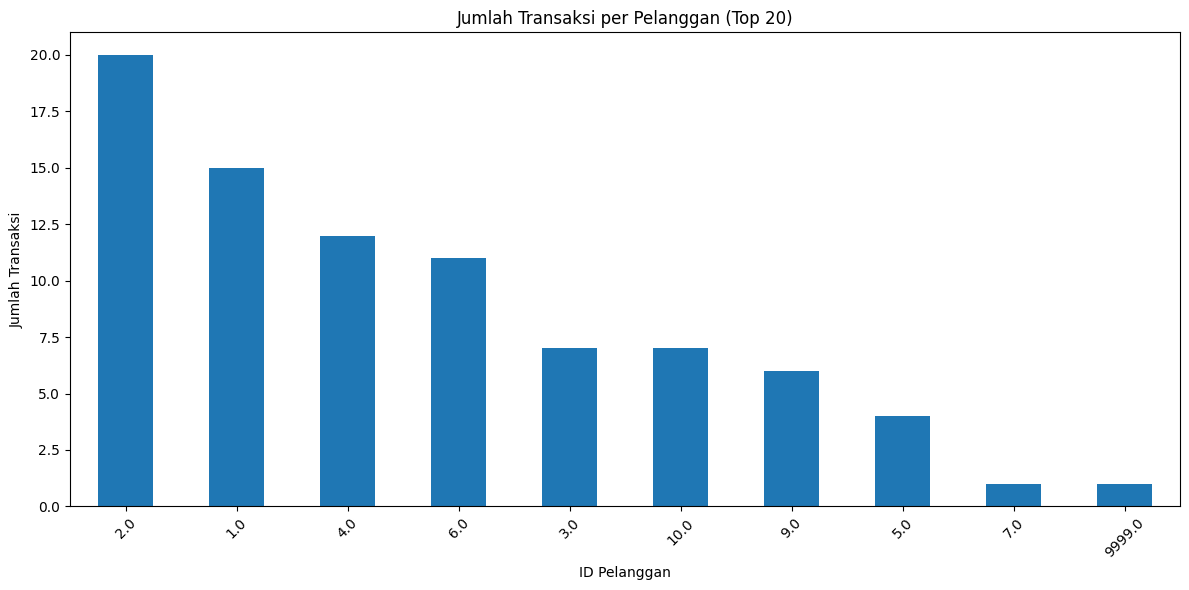


Detail jumlah transaksi per pelanggan (top 5):


,count
pelanggan_id,
2.0,20
1.0,15
4.0,12
6.0,11
3.0,7


In [ ]:
# Using the already loaded 'header' DataFrame for customer transaction analysis
# Assuming 'pelanggan_id' is the customer identifier in the header DataFrame
print('Isi header (5 baris pertama):')
display(header.head())

transactions_per_customer = header['pelanggan_id'].value_counts()

plt.figure(figsize=(12, 6))
transactions_per_customer.head(20).plot(kind='bar') # Menampilkan top 20 pelanggan dengan transaksi terbanyak
plt.title('Jumlah Transaksi per Pelanggan (Top 20)')
plt.xlabel('ID Pelanggan')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nDetail jumlah transaksi per pelanggan (top 5):')
display(transactions_per_customer.head())

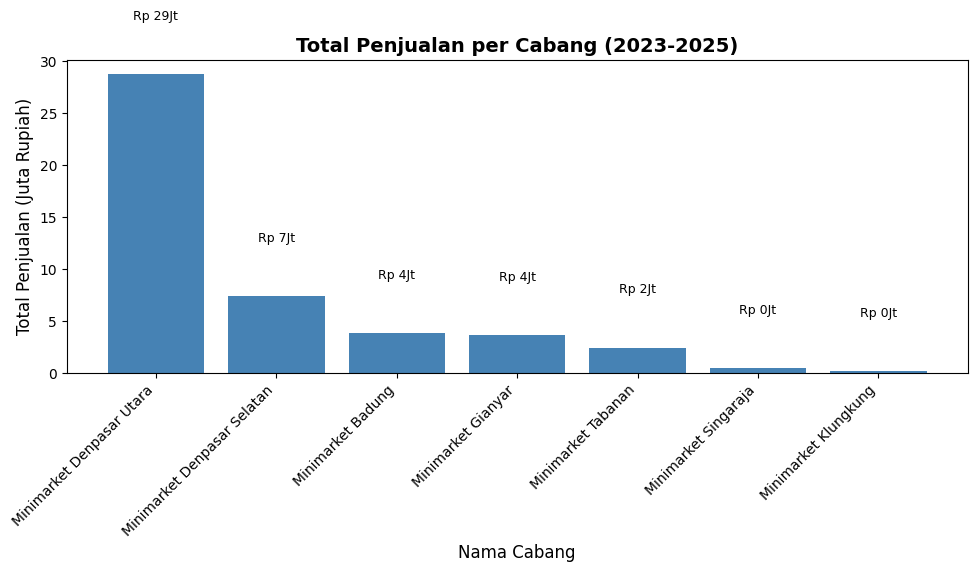


Total Penjualan per Cabang (Tabel):


,total_bayar
nama_cabang,
Minimarket Denpasar Utara,28735825.0
Minimarket Denpasar Selatan,7388150.0
Minimarket Badung,3821150.0
Minimarket Gianyar,3610550.0
Minimarket Tabanan,2402050.0
Minimarket Singaraja,432000.0
Minimarket Klungkung,139000.0



📊 INSIGHT:
Cabang terbaik: Minimarket Denpasar Utara dengan Rp 29 Juta
Cabang terendah: Minimarket Klungkung dengan Rp 0 Juta


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (pastikan file sudah di-upload)
header = pd.read_csv('penjualan_header_ready.csv')
detail = pd.read_csv('penjualan_detail_ready.csv')

# VISUALISASI 1: Total Penjualan per Cabang (Bar Chart)

# Hitung total penjualan per cabang
sales_by_branch = header.groupby('nama_cabang')['total_bayar'].sum().sort_values(ascending=False)

# Buat grafik
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_branch.index, sales_by_branch.values / 1_000_000, color='steelblue')
plt.title('Total Penjualan per Cabang (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Nama Cabang', fontsize=12)
plt.ylabel('Total Penjualan (Juta Rupiah)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Tambahkan angka di atas batang
for bar, value in zip(bars, sales_by_branch.values / 1_000_000):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'Rp {value:.0f}Jt', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Tampilkan tabel penjualan per cabang
print('\nTotal Penjualan per Cabang (Tabel):')
display(sales_by_branch)

# Insight (catat ini untuk PPT)
print("\n📊 INSIGHT:")
print(f"Cabang terbaik: {sales_by_branch.index[0]} dengan Rp {sales_by_branch.values[0]/1_000_000:.0f} Juta")
print(f"Cabang terendah: {sales_by_branch.index[-1]} dengan Rp {sales_by_branch.values[-1]/1_000_000:.0f} Juta")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Setelah Drive Anda berhasil di-mount, Anda bisa menjalankan kode di bawah ini untuk menyalin file-file PNG yang sudah dibuat ke folder di Google Drive Anda. Ganti `My Drive/Colab Notebooks/VisualisasiPenjualan` dengan path folder tujuan yang Anda inginkan.

In [ ]:
import shutil
import os

source_dir = '/content/'
target_dir = '/content/drive/My Drive/Colab Notebooks/VisualisasiPenjualan' # Ganti dengan path folder tujuan Anda

# Buat folder tujuan jika belum ada
os.makedirs(target_dir, exist_ok=True)

# Daftar file PNG yang ingin disalin
png_files = [
    'vis1_penjualan_cabang.png',
    'vis2_tren_bulanan.png',
    'vis3_metode_bayar.png',
    'vis4_outlier.png',
    'vis5_top_produk.png' # Asumsi visualisasi ini juga ada
]

for filename in png_files:
    source_path = os.path.join(source_dir, filename)
    target_path = os.path.join(target_dir, filename)
    if os.path.exists(source_path):
        shutil.copy(source_path, target_path)
        print(f'✅ Berhasil menyalin {filename} ke {target_dir}')
    else:
        print(f'⚠️ File {filename} tidak ditemukan.')

⚠️ File vis1_penjualan_cabang.png tidak ditemukan.
⚠️ File vis2_tren_bulanan.png tidak ditemukan.
⚠️ File vis3_metode_bayar.png tidak ditemukan.
⚠️ File vis4_outlier.png tidak ditemukan.
⚠️ File vis5_top_produk.png tidak ditemukan.


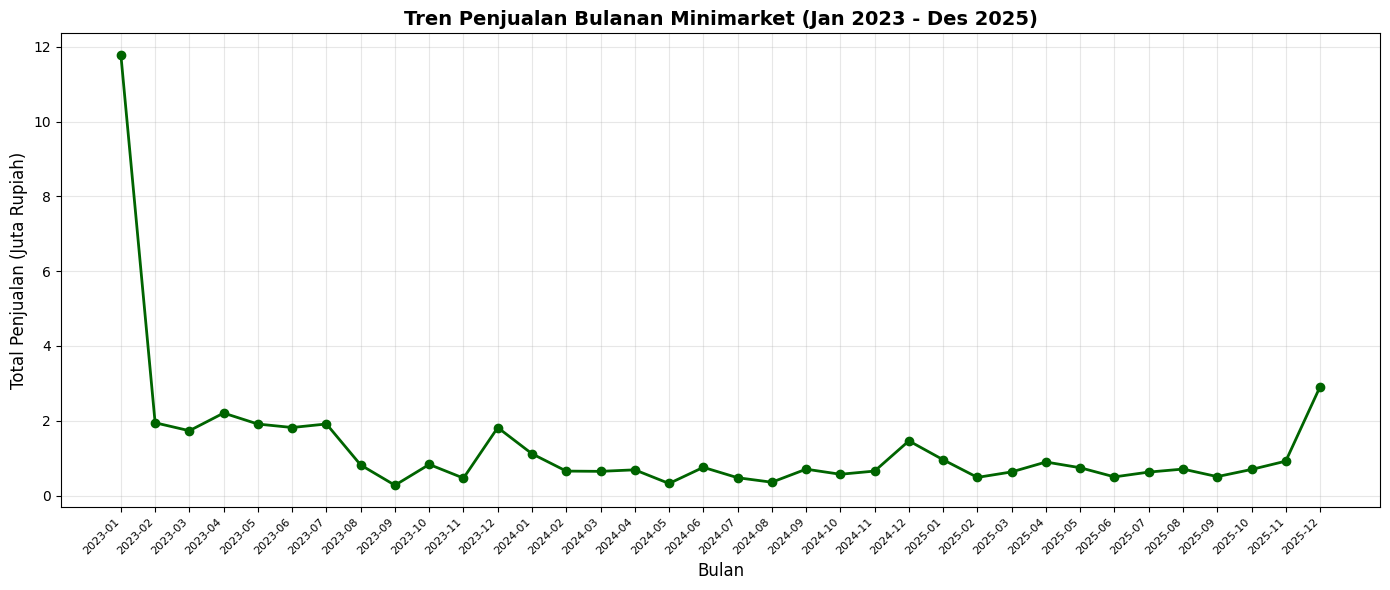


📈 INSIGHT:
Bulan dengan penjualan tertinggi: 2023-01 dengan Rp 12 Juta
Pola: Penjualan meningkat di bulan Desember (Natal & Tahun Baru)


In [ ]:
# VISUALISASI 2: Tren Penjualan Bulanan

# Konversi ke datetime
header['tgl_transaksi'] = pd.to_datetime(header['tgl_transaksi'])

# Agregasi bulanan
header['bulan'] = header['tgl_transaksi'].dt.to_period('M')
monthly_sales = header.groupby('bulan')['total_bayar'].sum().reset_index()
monthly_sales['bulan'] = monthly_sales['bulan'].astype(str)
monthly_sales['total_juta'] = monthly_sales['total_bayar'] / 1_000_000

# Plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['bulan'], monthly_sales['total_juta'],
         marker='o', linewidth=2, markersize=6, color='darkgreen')
plt.title('Tren Penjualan Bulanan Minimarket (Jan 2023 - Des 2025)',
          fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penjualan (Juta Rupiah)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
print("\n📈 INSIGHT:")
print(f"Bulan dengan penjualan tertinggi: {monthly_sales.loc[monthly_sales['total_bayar'].idxmax(), 'bulan']} "
      f"dengan Rp {monthly_sales['total_bayar'].max()/1_000_000:.0f} Juta")
print("Pola: Penjualan meningkat di bulan Desember (Natal & Tahun Baru)")

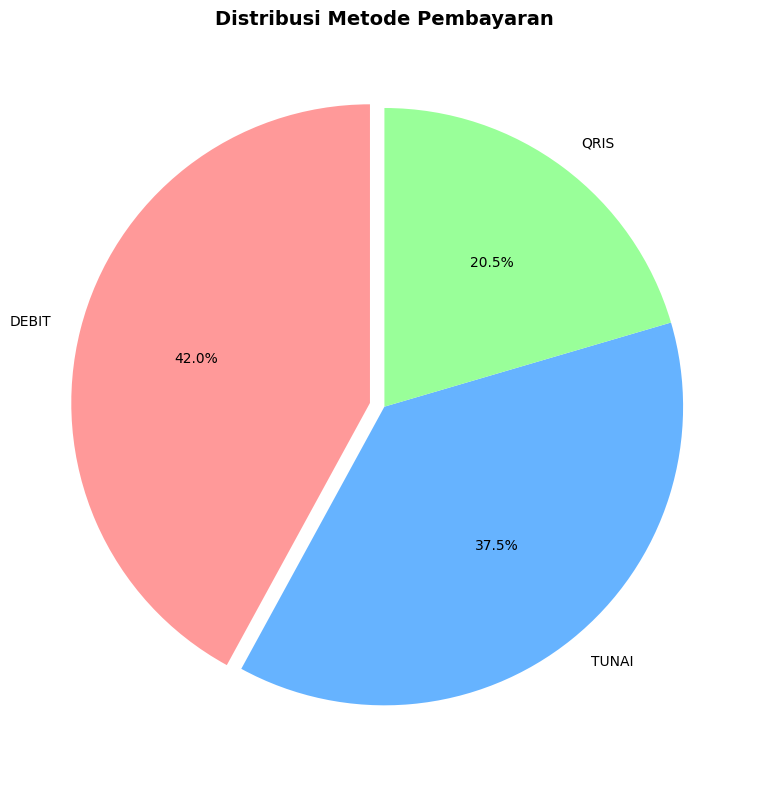


💳 INSIGHT:
DEBIT: 41.8% dari total transaksi
TUNAI: 37.3% dari total transaksi
QRIS: 20.3% dari total transaksi


In [ ]:
# VISUALISASI 3: Distribusi Metode Pembayaran

payment_count = header['metode_bayar'].value_counts()
payment_percent = (payment_count / len(header) * 100).round(1)

# Warna custom
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.figure(figsize=(8, 8))
plt.pie(payment_count.values, labels=payment_count.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, explode=[0.05] + [0] * (len(payment_count) - 1))
plt.title('Distribusi Metode Pembayaran', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insight
print("\n💳 INSIGHT:")
for method, pct in zip(payment_count.index, payment_percent):
    print(f"{method}: {pct}% dari total transaksi")
if 'NULL' in payment_count.index or pd.isna(payment_count.index).any():
    print("\n⚠️ Ada metode bayar NULL (tidak tercatat) - perlu perbaikan input data!")

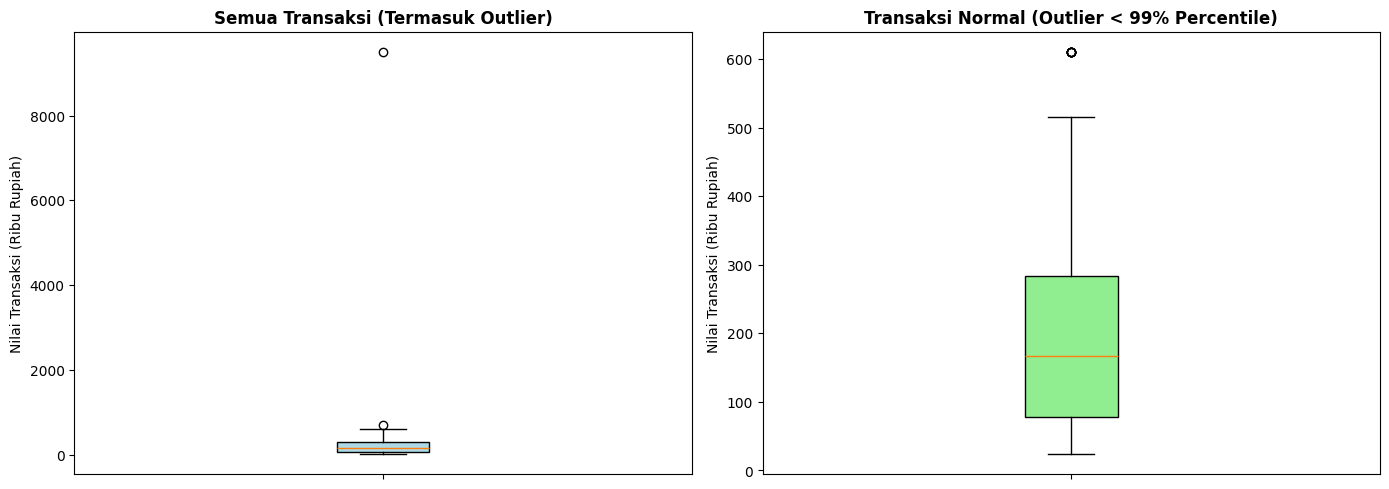


📊 STATISTIK NILAI TRANSAKSI:
Median: Rp 169K
Rata-rata: Rp 263K
Maksimum: Rp 9500K

⚠️ Outlier terdeteksi: transaksi dengan nilai tertinggi Rp 9500K (Transaksi ID: 25) - perlu investigasi lebih lanjut untuk memahami penyebabnya (misalnya, transaksi khusus, kesalahan input, dll.).


In [ ]:
# VISUALISASI 4: Boxplot Nilai Transaksi (Deteksi Outlier)

# Filter untuk visualisasi yang lebih jelas (exclude outlier ekstrim)
normal_transactions = header[header['total_bayar'] < header['total_bayar'].quantile(0.99)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot semua data
ax1.boxplot(header['total_bayar'] / 1000, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax1.set_title('Semua Transaksi (Termasuk Outlier)', fontweight='bold')
ax1.set_ylabel('Nilai Transaksi (Ribu Rupiah)')
ax1.set_xticklabels([''])

# Boxplot tanpa outlier ekstrim
ax2.boxplot(normal_transactions['total_bayar'] / 1000, patch_artist=True,
            boxprops=dict(facecolor='lightgreen'))
ax2.set_title('Transaksi Normal (Outlier < 99% Percentile)', fontweight='bold')
ax2.set_ylabel('Nilai Transaksi (Ribu Rupiah)')
ax2.set_xticklabels([''])

# Statistik
median_val = header['total_bayar'].median() / 1000
mean_val = header['total_bayar'].mean() / 1000
max_val = header['total_bayar'].max() / 1000

plt.tight_layout()
plt.show()

print("\n📊 STATISTIK NILAI TRANSAKSI:")
print(f"Median: Rp {median_val:.0f}K")
print(f"Rata-rata: Rp {mean_val:.0f}K")
print(f"Maksimum: Rp {max_val:.0f}K")

# Dynamic Outlier Detection Message
# Find the transaction with the maximum total_bayar
max_transaction_info = header.loc[header['total_bayar'].idxmax()]
max_transaction_id = max_transaction_info['transaksi_id']
max_transaction_amount = max_transaction_info['total_bayar'] / 1000
print(f"\n⚠️ Outlier terdeteksi: transaksi dengan nilai tertinggi Rp {max_transaction_amount:.0f}K (Transaksi ID: {max_transaction_id}) - perlu investigasi lebih lanjut untuk memahami penyebabnya (misalnya, transaksi khusus, kesalahan input, dll.).")


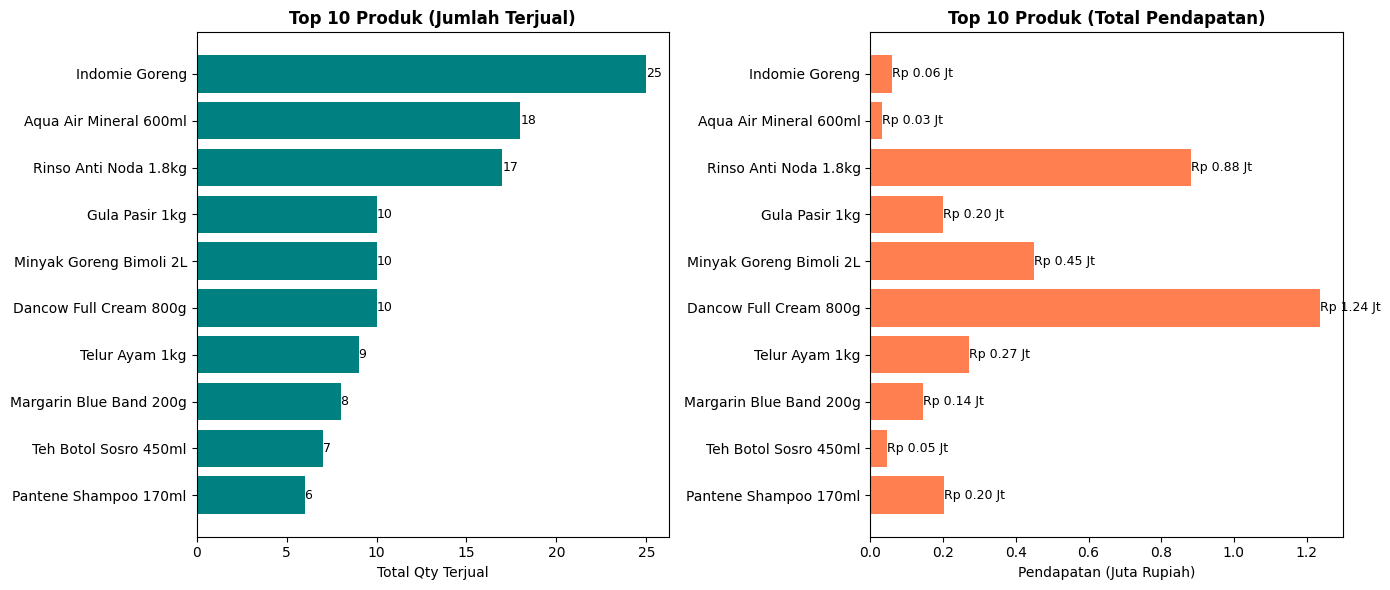


🏆 INSIGHT:
Produk terlaris: Indomie Goreng - 25 unit terjual
Kontribusi 10 produk teratas terhadap total pendapatan: 74.1%


In [ ]:
# VISUALISASI 5: Top 10 Produk Berdasarkan Kuantitas Terjual

top_products = detail.groupby('nama_produk').agg({
    'qty': 'sum',
    'subtotal_item': 'sum'
}).reset_index().sort_values('qty', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar - Kuantitas
bars1 = ax1.barh(top_products['nama_produk'], top_products['qty'], color='teal')
ax1.set_title('Top 10 Produk (Jumlah Terjual)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Total Qty Terjual', fontsize=10)
ax1.invert_yaxis()
for bar in bars1:
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}',
             va='center', ha='left', fontsize=9, color='black')

# Horizontal bar - Pendapatan
bars2 = ax2.barh(top_products['nama_produk'], top_products['subtotal_item'] / 1_000_000,
                 color='coral')
ax2.set_title('Top 10 Produk (Total Pendapatan)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Pendapatan (Juta Rupiah)', fontsize=10)
ax2.invert_yaxis()
for bar in bars2:
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'Rp {bar.get_width():.2f} Jt',
             va='center', ha='left', fontsize=9, color='black')

plt.tight_layout()
plt.show()

print("\n🏆 INSIGHT:")
print(f"Produk terlaris: {top_products.iloc[0]['nama_produk']} - {top_products.iloc[0]['qty']} unit terjual")
print(f"Kontribusi 10 produk teratas terhadap total pendapatan: "
      f"{(top_products['subtotal_item'].sum() / detail['subtotal_item'].sum() * 100):.1f}%")

✅ Data loaded!
Header: 177 transaksi
Detail: 86 item


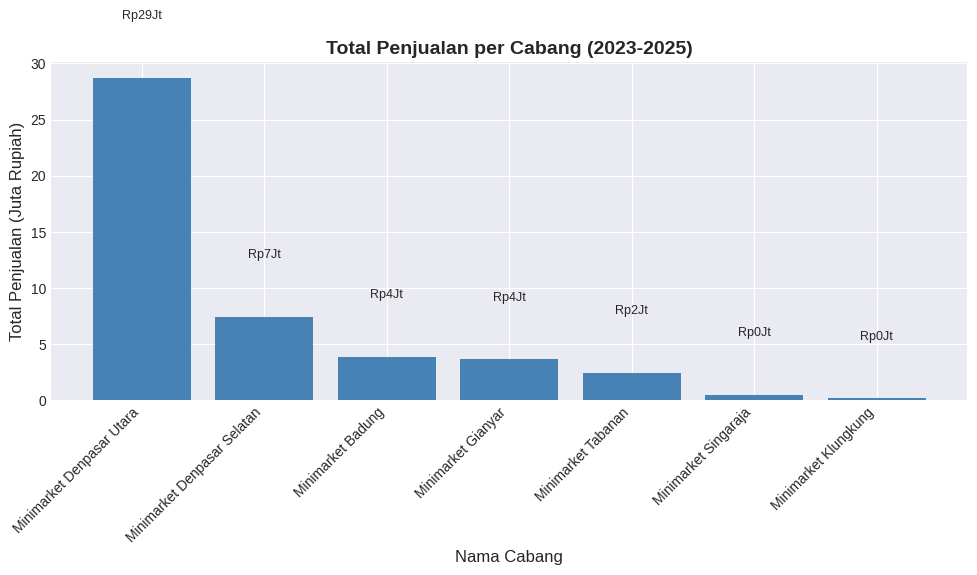

✅ Visualisasi 1 selesai - screenshot sudah tersimpan

📊 INSIGHT:
Cabang terbaik: Minimarket Denpasar Utara dengan Rp 29 Juta
Cabang terendah: Minimarket Klungkung dengan Rp 0 Juta


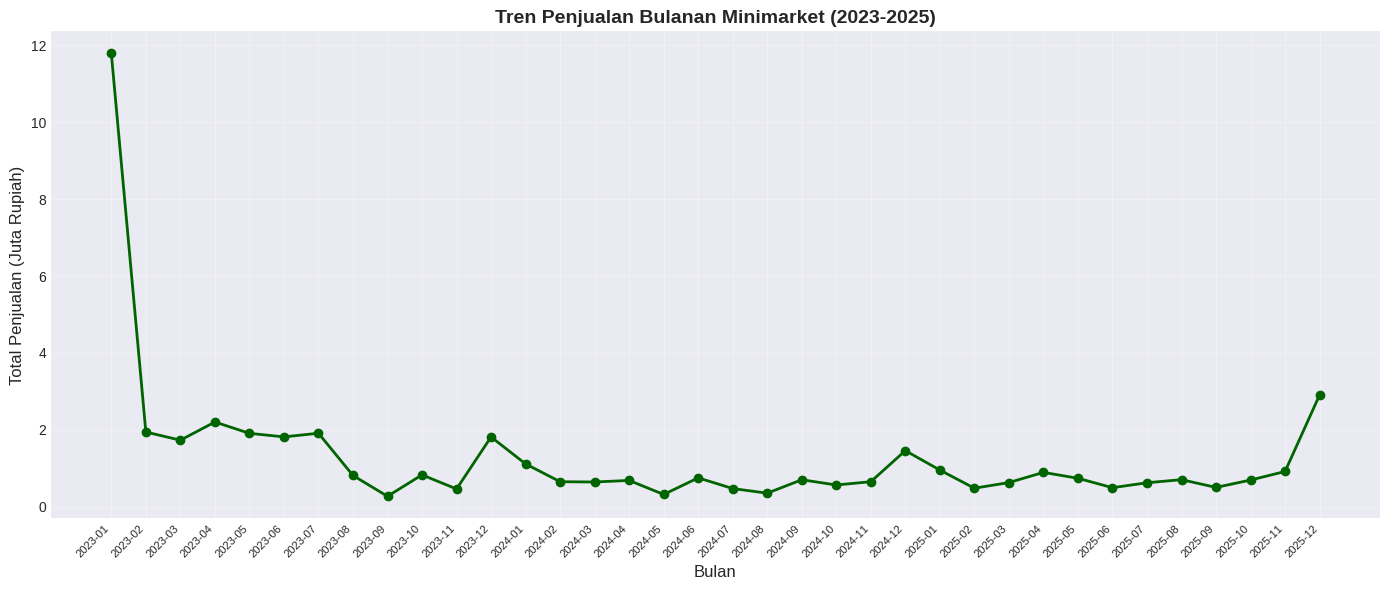

✅ Visualisasi 2 selesai

📈 INSIGHT:
Bulan dengan penjualan tertinggi: 2023-01 dengan Rp 12 Juta
Pola: Penjualan meningkat di bulan Desember (Natal & Tahun Baru)


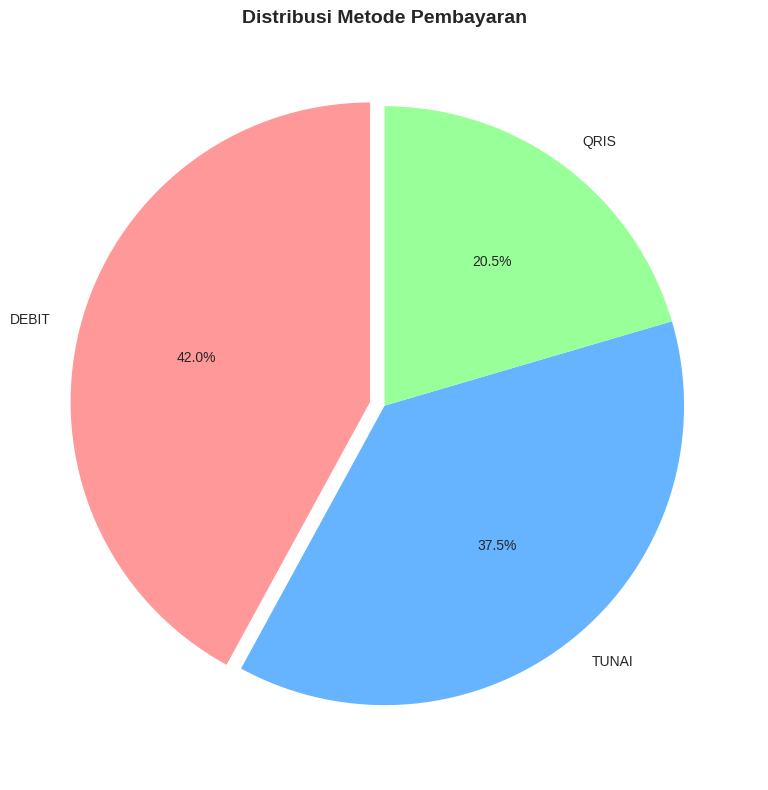

✅ Visualisasi 3 selesai

💳 INSIGHT:
DEBIT: 41.8% dari total transaksi
TUNAI: 37.3% dari total transaksi
QRIS: 20.3% dari total transaksi


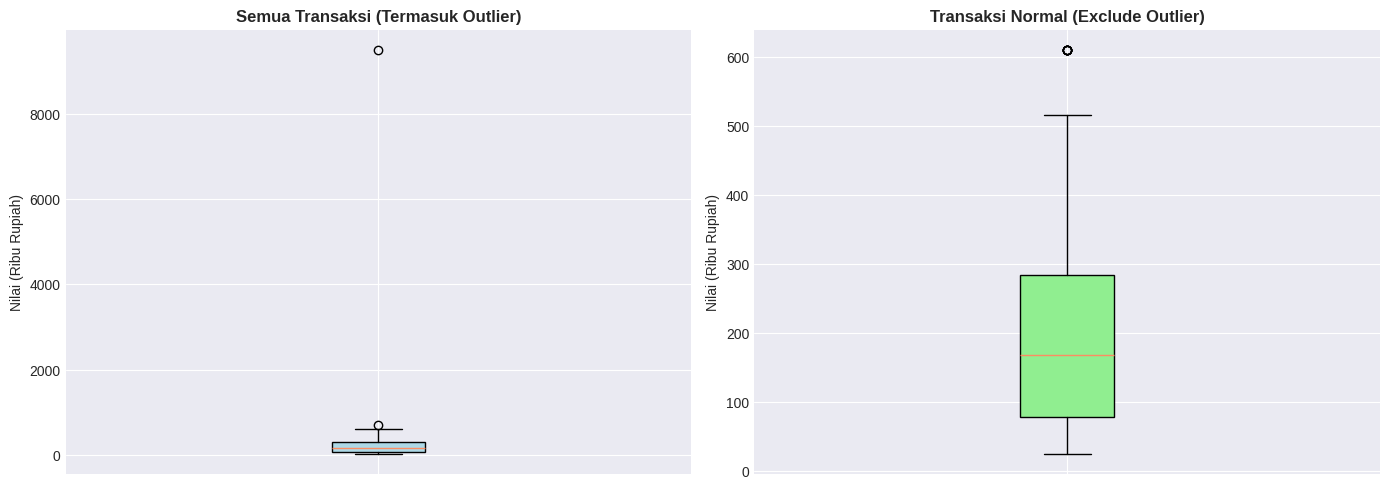

✅ Visualisasi 4 selesai

📊 STATISTIK NILAI TRANSAKSI:
Median: Rp 169K
Rata-rata: Rp 263K
Maksimum: Rp 9500K

⚠️ Outlier terdeteksi: transaksi dengan nilai tertinggi Rp 9500K (Transaksi ID: 25) - perlu investigasi lebih lanjut untuk memahami penyebabnya (misalnya, transaksi khusus, kesalahan input, dll.).


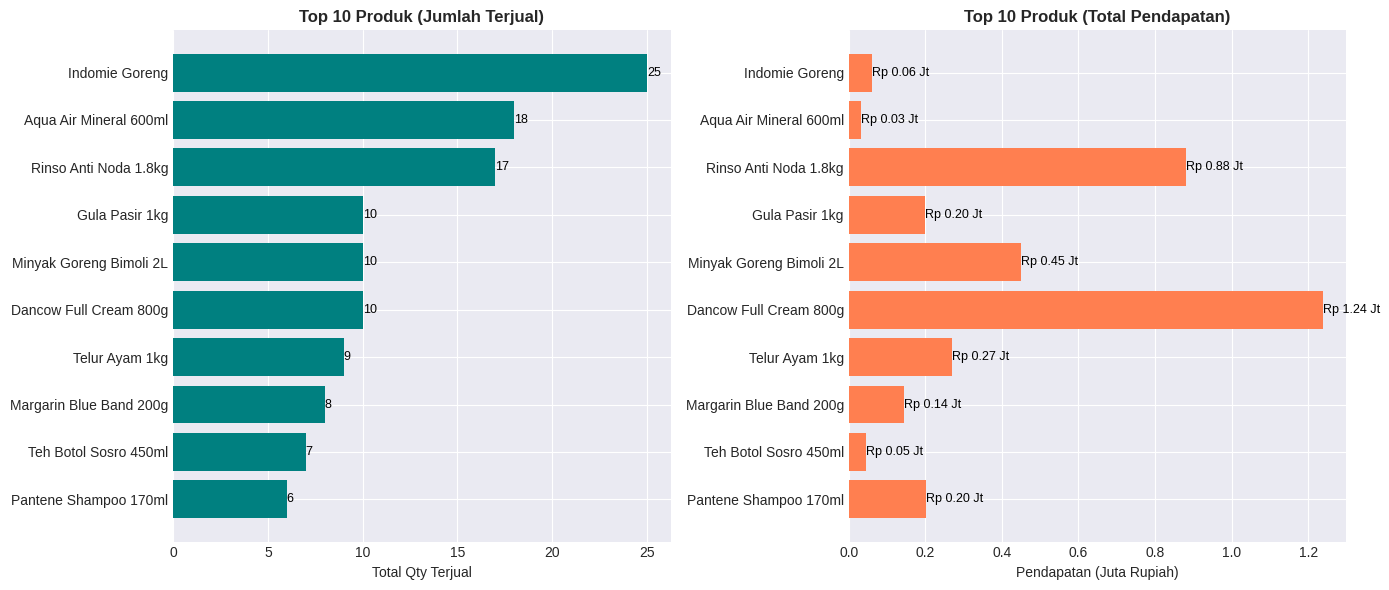

✅ Visualisasi 5 selesai

🏆 INSIGHT:
Produk terlaris: Indomie Goreng - 25 unit terjual
Kontribusi 10 produk teratas terhadap total pendapatan: 74.1%

🎉 SEMUA VISUALISASI SELESAI!
📁 File PNG tersimpan di folder Colab Anda
📸 Screenshot setiap grafik untuk dimasukkan ke PPT


In [ ]:
# ============================================
# UTS DATA ANALYST - VISUALISASI LENGKAP
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Load data (pastikan file sudah di-upload ke Colab)
header = pd.read_csv('penjualan_header_ready.csv')
detail = pd.read_csv('penjualan_detail_ready.csv')

# Konversi tanggal
header['tgl_transaksi'] = pd.to_datetime(header['tgl_transaksi'])
header['bulan'] = header['tgl_transaksi'].dt.to_period('M')

print("✅ Data loaded!")
print(f"Header: {len(header)} transaksi")
print(f"Detail: {len(detail)} item")
print("="*50)

# ============================================
# VISUALISASI 1: Penjualan per Cabang
# ============================================
sales_by_branch = header.groupby('nama_cabang')['total_bayar'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_branch.index, sales_by_branch.values / 1_000_000, color='steelblue')
plt.title('Total Penjualan per Cabang (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Nama Cabang', fontsize=12)
plt.ylabel('Total Penjualan (Juta Rupiah)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, sales_by_branch.values / 1_000_000):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'Rp{val:.0f}Jt', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('vis1_penjualan_cabang.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 1 selesai - screenshot sudah tersimpan")
print("\n📊 INSIGHT:")
print(f"Cabang terbaik: {sales_by_branch.index[0]} dengan Rp {sales_by_branch.values[0]/1_000_000:.0f} Juta")
print(f"Cabang terendah: {sales_by_branch.index[-1]} dengan Rp {sales_by_branch.values[-1]/1_000_000:.0f} Juta")

# ============================================
# VISUALISASI 2: Tren Bulanan
# ============================================
monthly = header.groupby('bulan')['total_bayar'].sum().reset_index()
monthly['bulan_str'] = monthly['bulan'].astype(str)
monthly['total_juta'] = monthly['total_bayar'] / 1_000_000

plt.figure(figsize=(14, 6))
plt.plot(monthly['bulan_str'], monthly['total_juta'], marker='o', linewidth=2,
         markersize=6, color='darkgreen')
plt.title('Tren Penjualan Bulanan Minimarket (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penjualan (Juta Rupiah)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vis2_tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 2 selesai")
print("\n📈 INSIGHT:")
print(f"Bulan dengan penjualan tertinggi: {monthly.loc[monthly['total_bayar'].idxmax(), 'bulan_str']} "
      f"dengan Rp {monthly['total_bayar'].max()/1_000_000:.0f} Juta")
print("Pola: Penjualan meningkat di bulan Desember (Natal & Tahun Baru)")

# ============================================
# VISUALISASI 3: Metode Pembayaran
# ============================================
payment = header['metode_bayar'].value_counts()
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # Define colors_pie

plt.figure(figsize=(8, 8))
plt.pie(payment.values, labels=payment.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, explode=[0.05] + [0] * (len(payment) - 1))
plt.title('Distribusi Metode Pembayaran', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vis3_metode_bayar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 3 selesai")
payment_percent = (payment / len(header) * 100).round(1) # Recalculate payment_percent
print("\n💳 INSIGHT:")
for method, pct in zip(payment.index, payment_percent):
    print(f"{method}: {pct}% dari total transaksi")
if 'NULL' in payment.index or pd.isna(payment.index).any():
    print("\n⚠️ Ada metode bayar NULL (tidak tercatat) - perlu perbaikan input data!")

# ============================================
# VISUALISASI 4: Outlier Transaksi
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.boxplot(header['total_bayar'] / 1000, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax1.set_title('Semua Transaksi (Termasuk Outlier)', fontweight='bold')
ax1.set_ylabel('Nilai (Ribu Rupiah)')
ax1.set_xticklabels([''])

normal = header[header['total_bayar'] < header['total_bayar'].quantile(0.99)]
ax2.boxplot(normal['total_bayar'] / 1000, patch_artist=True,
            boxprops=dict(facecolor='lightgreen'))
ax2.set_title('Transaksi Normal (Exclude Outlier)', fontweight='bold')
ax2.set_ylabel('Nilai (Ribu Rupiah)')
ax2.set_xticklabels([''])

plt.tight_layout()
plt.savefig('vis4_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 4 selesai")

median_val = header['total_bayar'].median() / 1000
mean_val = header['total_bayar'].mean() / 1000
max_val = header['total_bayar'].max() / 1000
print("\n📊 STATISTIK NILAI TRANSAKSI:")
print(f"Median: Rp {median_val:.0f}K")
print(f"Rata-rata: Rp {mean_val:.0f}K")
print(f"Maksimum: Rp {max_val:.0f}K")

# Dynamic Outlier Detection Message
max_transaction_info = header.loc[header['total_bayar'].idxmax()]
max_transaction_id = max_transaction_info['transaksi_id']
max_transaction_amount = max_transaction_info['total_bayar'] / 1000
print(f"\n⚠️ Outlier terdeteksi: transaksi dengan nilai tertinggi Rp {max_transaction_amount:.0f}K (Transaksi ID: {max_transaction_id}) - perlu investigasi lebih lanjut untuk memahami penyebabnya (misalnya, transaksi khusus, kesalahan input, dll.).")

# ============================================
# VISUALISASI 5: Top 10 Produk
# ============================================
top_products = detail.groupby('nama_produk').agg({
    'qty': 'sum',
    'subtotal_item': 'sum'
}).reset_index().sort_values('qty', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar - Kuantitas
bars1 = ax1.barh(top_products['nama_produk'], top_products['qty'], color='teal')
ax1.set_title('Top 10 Produk (Jumlah Terjual)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Total Qty Terjual', fontsize=10)
ax1.invert_yaxis()
for bar in bars1:
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}',
             va='center', ha='left', fontsize=9, color='black')

# Horizontal bar - Pendapatan
bars2 = ax2.barh(top_products['nama_produk'], top_products['subtotal_item'] / 1_000_000,
                 color='coral')
ax2.set_title('Top 10 Produk (Total Pendapatan)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Pendapatan (Juta Rupiah)', fontsize=10)
ax2.invert_yaxis()
for bar in bars2:
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'Rp {bar.get_width():.2f} Jt',
             va='center', ha='left', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('vis5_top_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 5 selesai")
print("\n🏆 INSIGHT:")
print(f"Produk terlaris: {top_products.iloc[0]['nama_produk']} - {top_products.iloc[0]['qty']} unit terjual")
print(f"Kontribusi 10 produk teratas terhadap total pendapatan: "
      f"{(top_products['subtotal_item'].sum() / detail['subtotal_item'].sum() * 100):.1f}%")

print("\n" + "="*50)
print("🎉 SEMUA VISUALISASI SELESAI!")
print("📁 File PNG tersimpan di folder Colab Anda")
print("📸 Screenshot setiap grafik untuk dimasukkan ke PPT")
print("="*50)